This notebook tries a couple different normalization strategies to avoid numerical instability caused by large numbers in the shendure dataset.

In [1]:
#imports
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import scMPRAforge as scm
import pandas as pd
import numpy as np

from dask.distributed import Client, LocalCluster

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
cluster=LocalCluster()

In [4]:
client = Client(cluster,
    timeout=f"{5*60}s",   # Client <-> scheduler timeout 
    heartbeat_interval="20s"  # Worker heartbeat interval
)

In [5]:
dat=scm.load_scMPRA_data("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres.tsv")
dat.drop("Unnamed: 0", axis=1, inplace=True)

In [6]:
def norm_umis_mpra_bc(tab,method):
    """
    Takes a mpra_umiwise table & performs normalization on `umis_mpra_bc`
    """

    valid_norm_options=["over100", "standard_scaler"]

    assert method in valid_norm_options, "invalid method"
    tabtype=scm.table_type(tab.columns)
    assert tabtype=="mpra_umiwise", "Malformed table."

    ret=tab.copy()

    if method=="over100":
        ret["umis_mpra_bc"]=ret["umis_mpra_bc"]/100
    else:
        raise NotImplementedError("method not implemented yet")
    
    return ret

# Over 100, no undo
Let's try a simple "divide all the data by 100" normalization

In [7]:
datover100=norm_umis_mpra_bc(tab=dat,method="over100")

In [8]:
primordialover100=scm.ortho()
primordialover100.criss_cross(client=client,dat=datover100)
primordialover100.extract_params(client)
batchover100=scm.simulation_batch(primordialover100)
batchover100.describe_primordial(client,datover100)

Metal device set to: Metal device set to: Apple M4 Pro
Apple M4 Pro

systemMemory: 24.00 GB

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB

maxCacheSize: 8.00 GB

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB



scMPRAforge: WARNING: [timed_fit] everybody took 2.20 seconds
scMPRAforge: WARNING: [timed_fit] nobody took 2.47 seconds
scMPRAforge: WARNING: [timed_fit] redgene took 2.51 seconds
scMPRAforge: WARNING: [timed_fit] somebody took 2.68 seconds
scMPRAforge: WARNING: [timed_fit] brain took 2.78 seconds
scMPRAforge: WARNING: [timed_fit] blood took 2.81 seconds
scMPRAforge: WARNING: [timed_fit] neurogene took 2.96 seconds


In [9]:
batchover100.simulate_many(client,3)
batchover100.fit_to_simulations(client)
batchover100._flatten_all_parameters()

scMPRAforge: WARNING: [timed_fit] somebody took 0.77 seconds
scMPRAforge: WARNING: [timed_fit] somebody took 1.03 seconds
scMPRAforge: WARNING: [timed_fit] nobody took 1.05 seconds
scMPRAforge: WARNING: [timed_fit] nobody took 1.14 seconds
scMPRAforge: WARNING: [timed_fit] neurogene took 1.20 seconds
scMPRAforge: WARNING: [timed_fit] everybody took 1.36 seconds
scMPRAforge: WARNING: [timed_fit] redgene took 1.35 seconds
scMPRAforge: WARNING: [timed_fit] everybody took 1.31 seconds
scMPRAforge: WARNING: [timed_fit] redgene took 1.31 seconds
scMPRAforge: WARNING: [timed_fit] brain took 1.33 seconds
scMPRAforge: WARNING: [timed_fit] neurogene took 1.54 seconds
scMPRAforge: WARNING: [timed_fit] redgene took 1.36 seconds
scMPRAforge: WARNING: [timed_fit] somebody took 1.04 seconds
scMPRAforge: WARNING: [timed_fit] nobody took 1.01 seconds
scMPRAforge: WARNING: [timed_fit] somebody took 1.07 seconds
scMPRAforge: WARNING: [timed_fit] somebody took 0.99 seconds
scMPRAforge: WARNING: [timed_fit

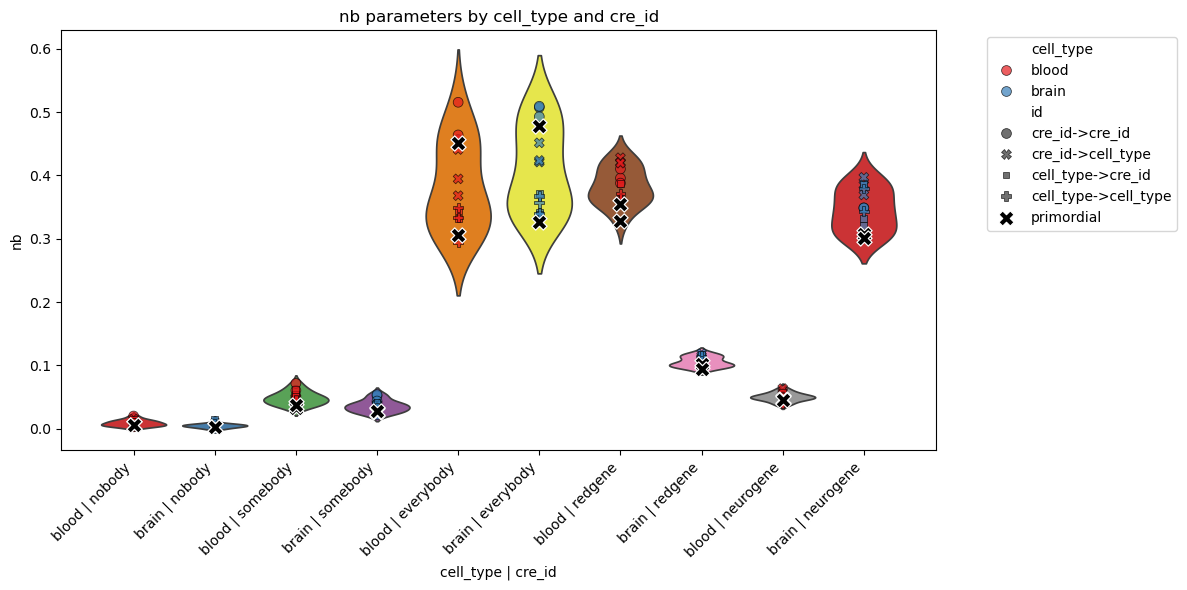

In [10]:
batchover100.plot_nb_spread()

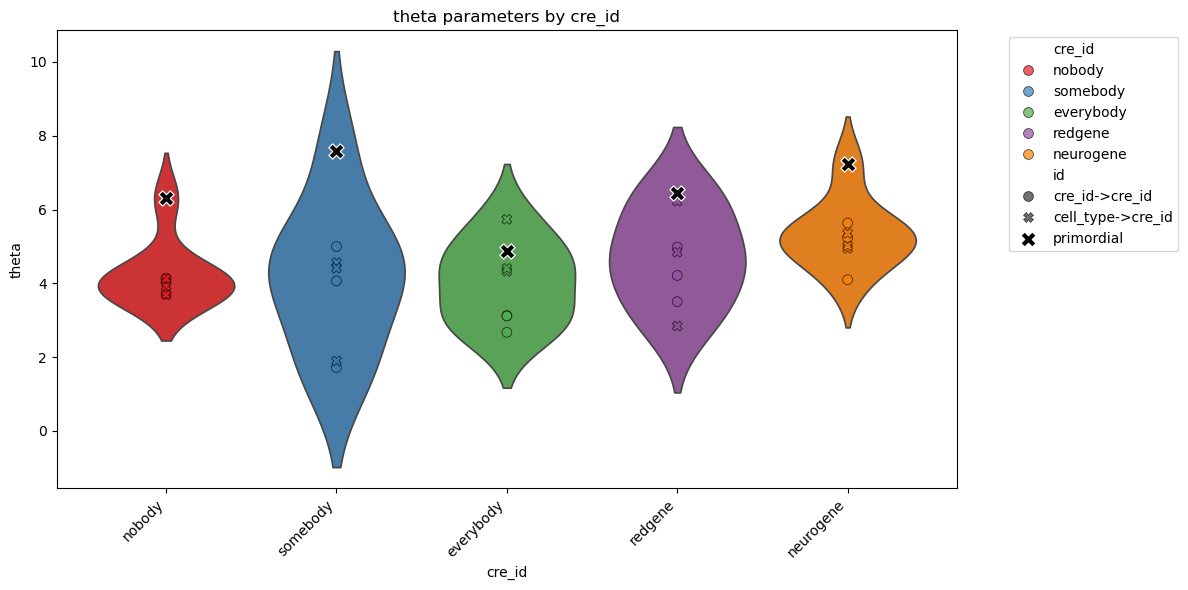

In [11]:
batchover100.plot_theta_spread("cre_id")

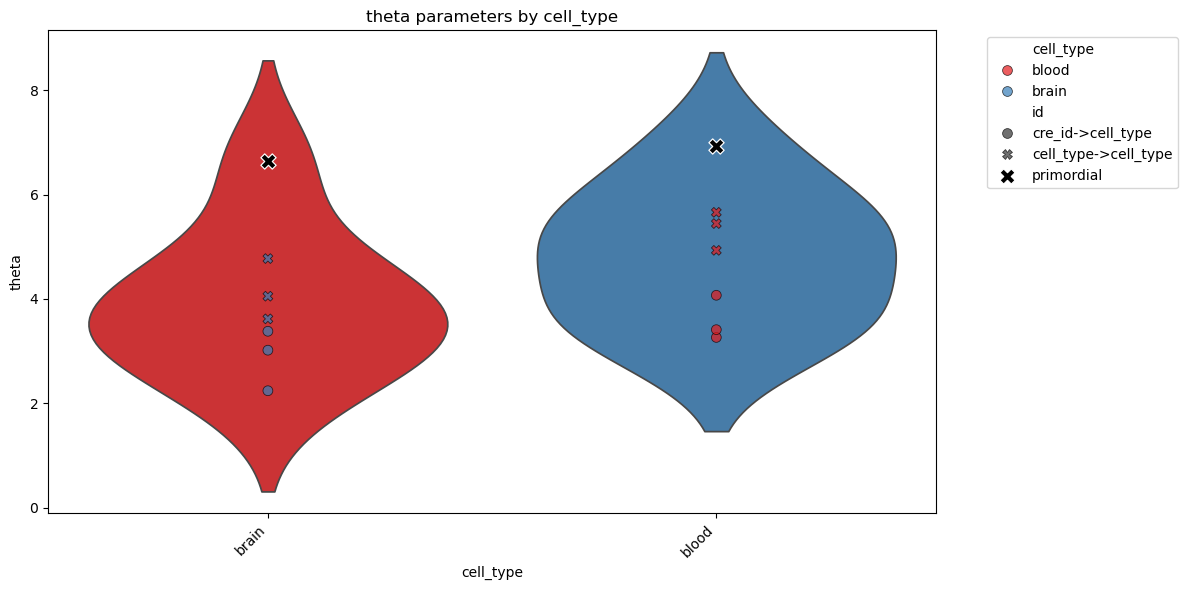

In [12]:
batchover100.plot_theta_spread("cell_type")

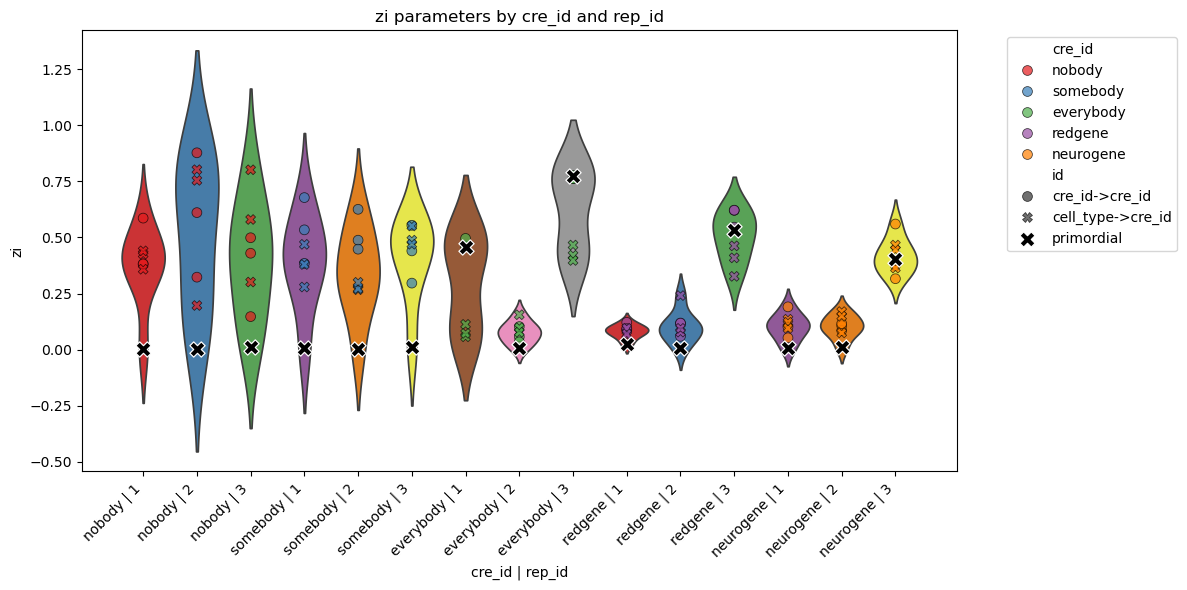

In [13]:
batchover100.plot_zi_spread("cre_id")

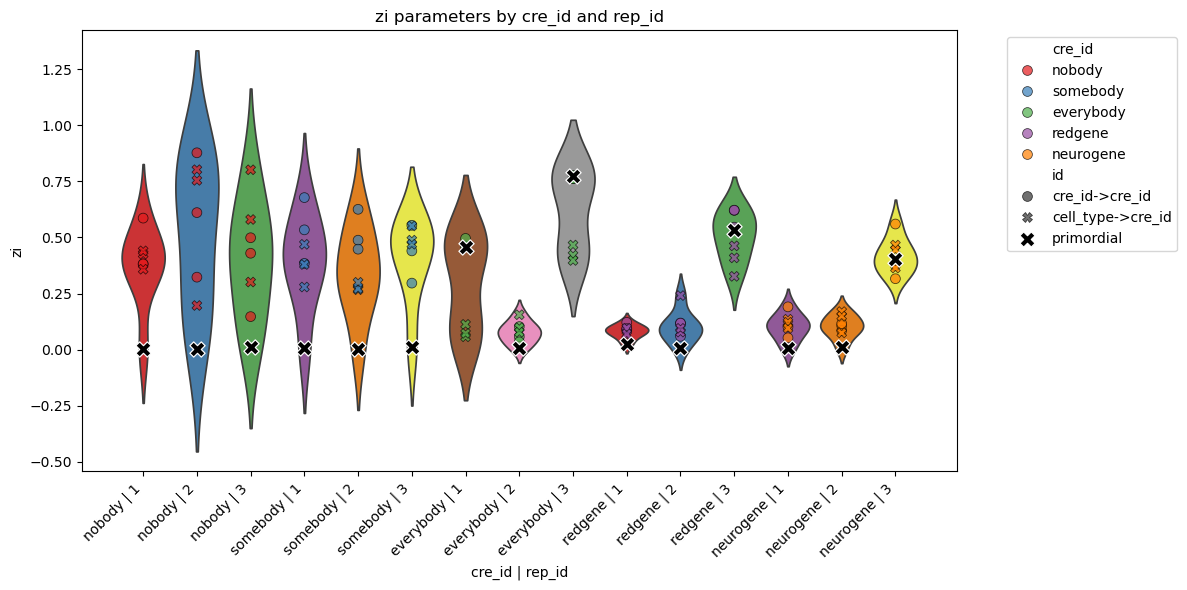

In [14]:
batchover100.plot_zi_spread("cre_id")

Not great performance. 
- ZI is borked for primordial, & there's wide spread among the simulated replicates
    - particularly bad is are the "zero zero inflation" estimates, since those won't be easially recoverable. 
- If true theta is ~1.2, then estimated theta should be ~1.2/100=0.012 which is not what we see

# over 100 with undo

Let's try a "normalize by dividing by 100 then undo that in the param estimates".

In [36]:
cluster.close()